import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

✓ Libraries imported


Load and Explore Data

In [4]:
df = pd.read_csv("/content/microgrid_data_realistic.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"Total rows: {len(df)}")
print(f"\nFault distribution:")
print(df['fault_type'].value_counts())
print(f"\nClass balance:")
print(f"  Normal:   {(df['fault_active'] == 0).sum()} ({(df['fault_active'] == 0).mean()*100:.1f}%)")
print(f"  Anomaly:  {(df['fault_active'] == 1).sum()} ({(df['fault_active'] == 1).mean()*100:.1f}%)")

DATASET OVERVIEW
Total rows: 2784

Fault distribution:
fault_type
normal            2229
grid_problem       104
heat_wave           97
battery_fault       93
cyber_attack        92
sensor_failure      86
inverter_trip       83
Name: count, dtype: int64

Class balance:
  Normal:   2229 (80.1%)
  Anomaly:  555 (19.9%)


 Advanced Feature Engineering

In [5]:
print("\n" + "="*70)
print("STEP 1: FEATURE ENGINEERING")
print("="*70)

# Make a copy
data = df.copy()

# ============================================
# 1. TIME-BASED FEATURES
# ============================================
data['hour'] = data['timestamp'].dt.hour
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
data['is_daytime'] = ((data['hour'] >= 6) & (data['hour'] <= 18)).astype(int)
data['is_peak_hours'] = ((data['hour'] >= 17) & (data['hour'] <= 21)).astype(int)

# ============================================
# 2. RATE OF CHANGE (detect sudden changes)
# ============================================
data['solar_change'] = data['solar_power_kw'].diff().abs().fillna(0)
data['load_change'] = data['load_demand_kw'].diff().abs().fillna(0)
data['soc_change'] = data['battery_soc_percent'].diff().abs().fillna(0)
data['voltage_change'] = data['grid_voltage_pu'].diff().abs().fillna(0)
data['frequency_change'] = data['grid_frequency_hz'].diff().abs().fillna(0)
data['battery_power_change'] = data['battery_power_kw'].diff().abs().fillna(0)

# Second derivative (acceleration)
data['solar_acceleration'] = data['solar_change'].diff().abs().fillna(0)
data['voltage_acceleration'] = data['voltage_change'].diff().abs().fillna(0)

# ============================================
# 3. ROLLING STATISTICS (context awareness)
# ============================================
for window in [4, 12, 24]:  # 1hr, 3hr, 6hr
    # Solar patterns
    data[f'solar_mean_{window}'] = data['solar_power_kw'].rolling(window, min_periods=1).mean()
    data[f'solar_std_{window}'] = data['solar_power_kw'].rolling(window, min_periods=1).std().fillna(0)
    data[f'solar_deviation_{window}'] = abs(data['solar_power_kw'] - data[f'solar_mean_{window}'])

    # Voltage patterns
    data[f'voltage_std_{window}'] = data['grid_voltage_pu'].rolling(window, min_periods=1).std().fillna(0)

    # Load patterns
    data[f'load_std_{window}'] = data['load_demand_kw'].rolling(window, min_periods=1).std().fillna(0)

# ============================================
# 4. DEVIATION FROM NORMAL (anomaly indicators)
# ============================================
data['voltage_deviation'] = abs(data['grid_voltage_pu'] - 1.0)
data['frequency_deviation'] = abs(data['grid_frequency_hz'] - 50.0)
data['voltage_low'] = (data['grid_voltage_pu'] < 0.95).astype(int)
data['voltage_high'] = (data['grid_voltage_pu'] > 1.05).astype(int)
data['frequency_low'] = (data['grid_frequency_hz'] < 49.8).astype(int)
data['frequency_high'] = (data['grid_frequency_hz'] > 50.2).astype(int)

# ============================================
# 5. SOLAR-IRRADIANCE CONSISTENCY
# ============================================
# Expected solar output
data['expected_solar'] = data['irradiance'] * 0.5
data['solar_error'] = abs(data['solar_power_kw'] - data['expected_solar'])
data['solar_error_pct'] = np.where(
    data['expected_solar'] > 10,
    (data['solar_error'] / (data['expected_solar'] + 1)) * 100,
    0
)

# Solar efficiency ratio
data['solar_efficiency'] = np.where(
    data['irradiance'] > 100,
    data['solar_power_kw'] / (data['irradiance'] + 1),
    0
)

# Irradiance without solar (inverter trip indicator)
data['irradiance_no_solar'] = ((data['irradiance'] > 200) & (data['solar_power_kw'] < 10)).astype(int)

# ============================================
# 6. TEMPERATURE ANOMALIES
# ============================================
data['battery_temp_high'] = (data['battery_temp_c'] > 45).astype(int)
data['pv_temp_high'] = (data['pv_temp_c'] > 60).astype(int)
data['inverter_temp_high'] = (data['inverter_temp_c'] > 65).astype(int)
data['temp_extreme'] = (data['temperature'] > 35).astype(int)

# Temperature change
data['battery_temp_change'] = data['battery_temp_c'].diff().abs().fillna(0)
data['pv_temp_change'] = data['pv_temp_c'].diff().abs().fillna(0)

# ============================================
# 7. BATTERY ANOMALIES
# ============================================
data['soc_extreme_low'] = (data['battery_soc_percent'] < 5).astype(int)
data['soc_extreme_high'] = (data['battery_soc_percent'] > 95).astype(int)

# Battery behavior inconsistencies
data['battery_inconsistent'] = (
    ((data['battery_power_kw'] > 50) & (data['battery_soc_percent'] < 10)) |  # High discharge when low
    ((data['battery_power_kw'] < -50) & (data['battery_soc_percent'] > 95))   # High charge when high
).astype(int)

# Battery power extreme
data['battery_power_high'] = (abs(data['battery_power_kw']) > 80).astype(int)

# ============================================
# 8. POWER BALANCE
# ============================================
data['net_power'] = data['solar_power_kw'] - data['load_demand_kw']
data['grid_dependency'] = abs(data['grid_power_kw']) / (data['load_demand_kw'] + 1)

# Energy balance check
data['energy_balance'] = abs(
    data['solar_power_kw'] + data['battery_power_kw'] + data['grid_power_kw'] - data['load_demand_kw']
)
data['energy_imbalance'] = (data['energy_balance'] > 1).astype(int)

# ============================================
# 9. LAG FEATURES (temporal context)
# ============================================
for lag in [1, 4, 12]:
    data[f'solar_lag_{lag}'] = data['solar_power_kw'].shift(lag).fillna(0)
    data[f'voltage_lag_{lag}'] = data['grid_voltage_pu'].shift(lag).fillna(0)
    data[f'fault_lag_{lag}'] = data['fault_active'].shift(lag).fillna(0)

# ============================================
# 10. INTERACTION FEATURES
# ============================================
data['voltage_freq_product'] = data['voltage_deviation'] * data['frequency_deviation']
data['temp_irradiance_interaction'] = data['temperature'] * data['irradiance'] / 1000
data['load_price_interaction'] = data['load_demand_kw'] * data['electricity_price_per_kwh']

# Fill any remaining NaN
data = data.fillna(0)

# Count features
feature_cols = [c for c in data.columns if c not in ['timestamp', 'fault_active', 'fault_type', 'date']]
print(f"\n✓ Total features created: {len(feature_cols)}")
print(f"  - Base features: 13")
print(f"  - Time features: 5")
print(f"  - Rate of change: 8")
print(f"  - Rolling stats: {len([c for c in feature_cols if 'rolling' in c or 'mean' in c or 'std' in c or 'deviation' in c])}")
print(f"  - Anomaly indicators: {len([c for c in feature_cols if 'high' in c or 'low' in c or 'extreme' in c or 'inconsistent' in c])}")
print(f"  - Lag features: 9")
print(f"  - Others: {len(feature_cols) - 13 - 5 - 8 - 9}")


STEP 1: FEATURE ENGINEERING

✓ Total features created: 96
  - Base features: 13
  - Time features: 5
  - Rate of change: 8
  - Rolling stats: 17
  - Anomaly indicators: 12
  - Lag features: 9
  - Others: 61


 Prepare Train/Test Sets

In [6]:
print("\n" + "="*70)
print("STEP 2: TRAIN/TEST SPLIT")
print("="*70)

# Select features
X = data[feature_cols].copy()
y = data['fault_active'].copy()

# Time-based split (80/20)
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\nTrain set: {len(X_train)} samples")
print(f"  Normal:  {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Anomaly: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

print(f"\nTest set: {len(X_test)} samples")
print(f"  Normal:  {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Anomaly: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled")


STEP 2: TRAIN/TEST SPLIT

Train set: 2227 samples
  Normal:  1790 (80.4%)
  Anomaly: 437 (19.6%)

Test set: 557 samples
  Normal:  439 (78.8%)
  Anomaly: 118 (21.2%)

✓ Features scaled


Handle Class Imbalance with SMOTE

In [7]:
print("\n" + "="*70)
print("STEP 3: CLASS BALANCING WITH SMOTE")
print("="*70)

print(f"\nBefore SMOTE:")
print(f"  Normal:  {(y_train == 0).sum()}")
print(f"  Anomaly: {(y_train == 1).sum()}")
print(f"  Ratio:   1:{(y_train == 0).sum() / (y_train == 1).sum():.1f}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  Normal:  {(y_train_balanced == 0).sum()}")
print(f"  Anomaly: {(y_train_balanced == 1).sum()}")
print(f"  Ratio:   1:{(y_train_balanced == 0).sum() / (y_train_balanced == 1).sum():.1f}")

print("\n✓ Classes balanced")


STEP 3: CLASS BALANCING WITH SMOTE

Before SMOTE:
  Normal:  1790
  Anomaly: 437
  Ratio:   1:4.1

After SMOTE:
  Normal:  1790
  Anomaly: 1790
  Ratio:   1:1.0

✓ Classes balanced


Train Optimized Random Forest

In [8]:
print("\n" + "="*70)
print("STEP 4: TRAINING RANDOM FOREST")
print("="*70)

# Train Random Forest with optimized parameters
rf_model = RandomForestClassifier(
    n_estimators=300,           # More trees
    max_depth=25,               # Deeper trees
    min_samples_split=5,        # Allow smaller splits
    min_samples_leaf=2,         # Smaller leaf nodes
    max_features='sqrt',        # Feature subsampling
    class_weight=None,          # Already balanced with SMOTE
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1,                  # Use all CPU cores
    verbose=1
)

print("Training Random Forest...")
rf_model.fit(X_train_balanced, y_train_balanced)

print(f"\n✓ Training complete!")
print(f"  OOB Score: {rf_model.oob_score_:.3f}")


STEP 4: TRAINING RANDOM FOREST
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    5.9s finished



✓ Training complete!
  OOB Score: 0.959


Optimize Decision Threshold

In [9]:
print("\n" + "="*70)
print("STEP 5: THRESHOLD OPTIMIZATION")
print("="*70)

# Get prediction probabilities
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Test different thresholds
print("\nTesting thresholds from 0.20 to 0.80...")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 44)

threshold_results = []
for threshold in np.arange(0.20, 0.81, 0.05):
    y_pred_temp = (y_pred_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_temp)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    print(f"{threshold:>10.2f} {precision:>10.3f} {recall:>10.3f} {f1:>10.3f}")

# Find best threshold
threshold_df = pd.DataFrame(threshold_results)
best_idx = threshold_df['f1'].idxmax()
best_threshold = threshold_df.loc[best_idx, 'threshold']
best_precision = threshold_df.loc[best_idx, 'precision']
best_recall = threshold_df.loc[best_idx, 'recall']
best_f1 = threshold_df.loc[best_idx, 'f1']

print("\n" + "="*70)
print(f"🎯 OPTIMAL THRESHOLD: {best_threshold:.2f}")
print("="*70)
print(f"  Precision: {best_precision:.3f}")
print(f"  Recall:    {best_recall:.3f}")
print(f"  F1-Score:  {best_f1:.3f}")

# Make final predictions with optimal threshold
y_pred_final = (y_pred_proba >= best_threshold).astype(int)


STEP 5: THRESHOLD OPTIMIZATION

Testing thresholds from 0.20 to 0.80...
 Threshold  Precision     Recall   F1-Score
--------------------------------------------
      0.20      0.322      0.831      0.464
      0.25      0.464      0.712      0.562
      0.30      0.659      0.686      0.672
      0.35      0.843      0.636      0.725
      0.40      0.935      0.610      0.738
      0.45      1.000      0.585      0.738
      0.50      1.000      0.551      0.710
      0.55      1.000      0.525      0.689
      0.60      1.000      0.508      0.674
      0.65      1.000      0.492      0.659
      0.70      1.000      0.492      0.659


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished


      0.75      1.000      0.475      0.644
      0.80      1.000      0.458      0.628

🎯 OPTIMAL THRESHOLD: 0.40
  Precision: 0.935
  Recall:    0.610
  F1-Score:  0.738


Evaluate Performance

In [10]:
print("\n" + "="*70)
print("STEP 6: FINAL EVALUATION")
print("="*70)

# Detailed classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_final,
                          target_names=['Normal', 'Anomaly'],
                          digits=3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
print("\n📋 Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]:4d} (correctly identified normal)")
print(f"False Positives: {cm[0,1]:4d} (false alarms)")
print(f"False Negatives: {cm[1,0]:4d} (missed anomalies)")
print(f"True Positives:  {cm[1,1]:4d} (correctly detected anomalies)")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
false_alarm_rate = fp / (fp + tn)
miss_rate = fn / (fn + tp)

print(f"\n📉 Additional Metrics:")
print(f"  Specificity (True Negative Rate): {specificity:.3f}")
print(f"  False Alarm Rate:                 {false_alarm_rate:.3f}")
print(f"  Miss Rate:                        {miss_rate:.3f}")
print(f"  ROC-AUC Score:                    {roc_auc_score(y_test, y_pred_proba):.3f}")

# Detection rate by fault type
print(f"\n🎯 Detection Rate by Fault Type:")
test_data = data.iloc[split_idx:].copy()
test_data['predicted'] = y_pred_final

for fault_type in sorted(test_data['fault_type'].unique()):
    if fault_type != 'normal':
        fault_subset = test_data[test_data['fault_type'] == fault_type]
        detected = (fault_subset['predicted'] == 1).sum()
        total = len(fault_subset)
        rate = (detected / total * 100) if total > 0 else 0
        print(f"  {fault_type:20s}: {detected:3d}/{total:3d} ({rate:5.1f}%)")


STEP 6: FINAL EVALUATION

📊 Classification Report:
              precision    recall  f1-score   support

      Normal      0.904     0.989     0.945       439
     Anomaly      0.935     0.610     0.738       118

    accuracy                          0.908       557
   macro avg      0.920     0.799     0.841       557
weighted avg      0.911     0.908     0.901       557


📋 Confusion Matrix:
[[434   5]
 [ 46  72]]

True Negatives:   434 (correctly identified normal)
False Positives:    5 (false alarms)
False Negatives:   46 (missed anomalies)
True Positives:    72 (correctly detected anomalies)

📉 Additional Metrics:
  Specificity (True Negative Rate): 0.989
  False Alarm Rate:                 0.011
  Miss Rate:                        0.390
  ROC-AUC Score:                    0.830

🎯 Detection Rate by Fault Type:
  battery_fault       :   1/ 23 (  4.3%)
  cyber_attack        :   1/ 13 (  7.7%)
  grid_problem        :  16/ 16 (100.0%)
  heat_wave           :  26/ 26 (100.0%)
  inv

Feature Importance Analysis

In [11]:
print("\n" + "="*70)
print("STEP 7: FEATURE IMPORTANCE")
print("="*70)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🏆 Top 20 Most Important Features:")
for idx, row in feature_importance.head(20).iterrows():
    print(f"  {row['feature']:35s}: {row['importance']:.4f}")

# Save for visualization
feature_importance.to_csv('feature_importance_rf.csv', index=False)
print("\n✓ Feature importance saved to 'feature_importance_rf.csv'")


STEP 7: FEATURE IMPORTANCE

🏆 Top 20 Most Important Features:
  pv_temp_change                     : 0.0472
  grid_voltage_pu                    : 0.0447
  temperature                        : 0.0376
  data_quality                       : 0.0371
  voltage_deviation                  : 0.0345
  battery_temp_c                     : 0.0340
  inverter_temp_c                    : 0.0329
  voltage_low                        : 0.0264
  voltage_freq_product               : 0.0263
  solar_target_4hr                   : 0.0251
  voltage_change                     : 0.0217
  voltage_acceleration               : 0.0207
  battery_temp_change                : 0.0181
  pv_temp_c                          : 0.0179
  temp_extreme                       : 0.0166
  fault_lag_12                       : 0.0151
  solar_target_15min                 : 0.0147
  solar_target_24hr                  : 0.0131
  grid_power_kw                      : 0.0131
  battery_soh                        : 0.0123

✓ Feature import

Visualizations


STEP 8: CREATING VISUALIZATIONS


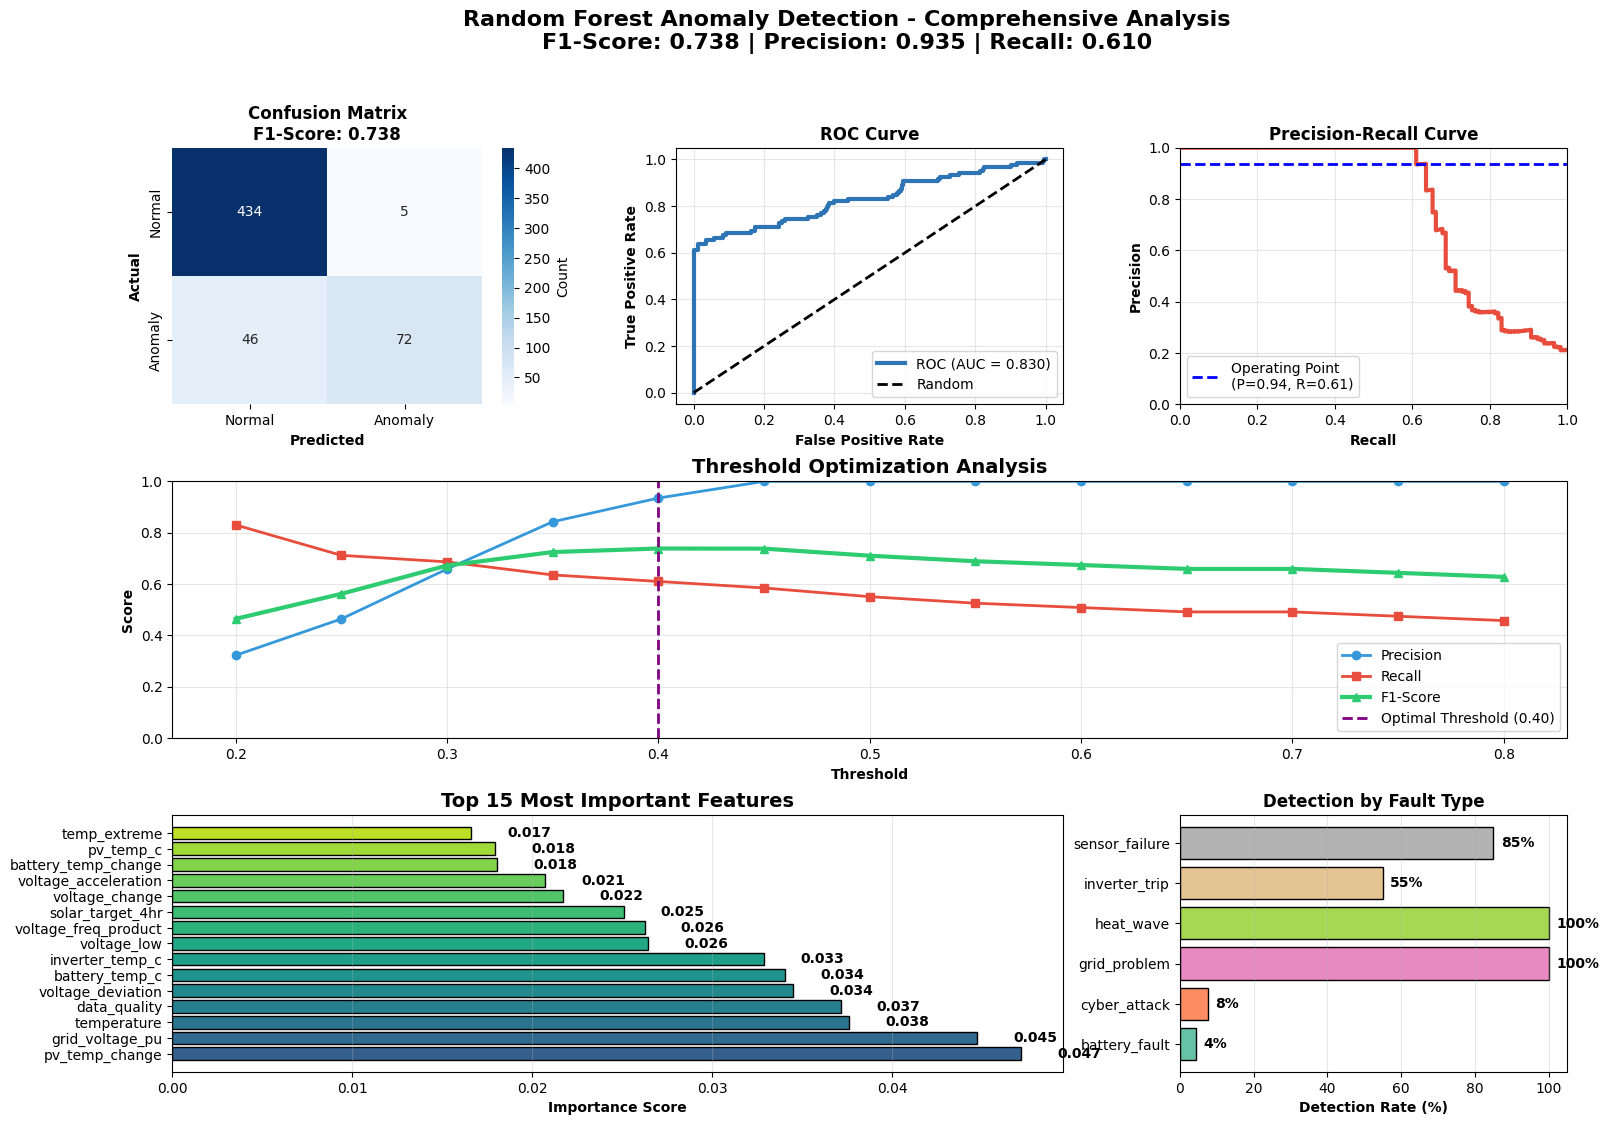


✓ Visualization saved as 'random_forest_anomaly_detection.png'


In [12]:
print("\n" + "="*70)
print("STEP 8: CREATING VISUALIZATIONS")
print("="*70)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontweight='bold')
ax1.set_ylabel('Actual', fontweight='bold')
ax1.set_title(f'Confusion Matrix\nF1-Score: {best_f1:.3f}', fontweight='bold')

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
ax2.plot(fpr, tpr, linewidth=3, label=f'ROC (AUC = {roc_auc:.3f})', color='#2E75B6')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
ax3.plot(recall_vals, precision_vals, linewidth=3, color='#E74C3C')
ax3.axhline(y=best_precision, color='blue', linestyle='--', linewidth=2,
            label=f'Operating Point\n(P={best_precision:.2f}, R={best_recall:.2f})')
ax3.set_xlabel('Recall', fontweight='bold')
ax3.set_ylabel('Precision', fontweight='bold')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1])

# 4. Threshold Analysis
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(threshold_df['threshold'], threshold_df['precision'],
         marker='o', linewidth=2, label='Precision', color='#3498DB')
ax4.plot(threshold_df['threshold'], threshold_df['recall'],
         marker='s', linewidth=2, label='Recall', color='#E74C3C')
ax4.plot(threshold_df['threshold'], threshold_df['f1'],
         marker='^', linewidth=3, label='F1-Score', color='#2ECC71')
ax4.axvline(x=best_threshold, color='purple', linestyle='--', linewidth=2,
            label=f'Optimal Threshold ({best_threshold:.2f})')
ax4.set_xlabel('Threshold', fontweight='bold')
ax4.set_ylabel('Score', fontweight='bold')
ax4.set_title('Threshold Optimization Analysis', fontweight='bold', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1])

# 5. Feature Importance (Top 15)
ax5 = fig.add_subplot(gs[2, :2])
top15 = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top15)))
bars = ax5.barh(range(len(top15)), top15['importance'], color=colors, edgecolor='black')
ax5.set_yticks(range(len(top15)))
ax5.set_yticklabels(top15['feature'])
ax5.set_xlabel('Importance Score', fontweight='bold')
ax5.set_title('Top 15 Most Important Features', fontweight='bold', fontsize=14)
ax5.grid(axis='x', alpha=0.3)
# Add values
for i, (bar, val) in enumerate(zip(bars, top15['importance'])):
    ax5.text(val + 0.002, i, f'{val:.3f}', va='center', fontweight='bold')

# 6. Detection Rate by Fault Type
ax6 = fig.add_subplot(gs[2, 2])
fault_detection_data = []
for fault_type in sorted(test_data['fault_type'].unique()):
    if fault_type != 'normal':
        fault_subset = test_data[test_data['fault_type'] == fault_type]
        rate = (fault_subset['predicted'] == 1).mean() * 100
        fault_detection_data.append((fault_type, rate))

fault_types = [x[0] for x in fault_detection_data]
detection_rates = [x[1] for x in fault_detection_data]
colors_faults = plt.cm.Set2(np.linspace(0, 1, len(fault_types)))
bars = ax6.barh(fault_types, detection_rates, color=colors_faults, edgecolor='black')
ax6.set_xlabel('Detection Rate (%)', fontweight='bold')
ax6.set_title('Detection by Fault Type', fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, detection_rates)):
    ax6.text(val + 2, i, f'{val:.0f}%', va='center', fontweight='bold')

plt.suptitle(f'Random Forest Anomaly Detection - Comprehensive Analysis\nF1-Score: {best_f1:.3f} | Precision: {best_precision:.3f} | Recall: {best_recall:.3f}',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('random_forest_anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'random_forest_anomaly_detection.png'")

Summary & Export

In [13]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

summary = f"""
🎯 RANDOM FOREST ANOMALY DETECTION RESULTS

Dataset:
  Total samples:        {len(data)}
  Training samples:     {len(X_train)}
  Test samples:         {len(X_test)}
  Test anomalies:       {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)

Feature Engineering:
  Total features:       {len(feature_cols)}
  Feature categories:   Time, Rate-of-Change, Rolling Stats, Anomaly Flags, Lags

Model Configuration:
  Algorithm:            Random Forest
  Number of trees:      {rf_model.n_estimators}
  Max depth:            {rf_model.max_depth}
  Class balancing:      SMOTE
  Optimal threshold:    {best_threshold:.2f}

Performance Metrics:
  Precision:            {best_precision:.3f}
  Recall:               {best_recall:.3f}
  F1-Score:             {best_f1:.3f}
  ROC-AUC:              {roc_auc_score(y_test, y_pred_proba):.3f}
  Specificity:          {specificity:.3f}

  True Positives:       {tp}
  True Negatives:       {tn}
  False Positives:      {fp}
  False Negatives:      {fn}

Top 5 Important Features:
"""

for idx, row in feature_importance.head(5).iterrows():
    summary += f"  {idx+1}. {row['feature']:30s}: {row['importance']:.4f}\n"

print(summary)

# Save summary
with open('anomaly_detection_summary.txt', 'w') as f:
    f.write(summary)

# Save predictions
results_df = test_data[['timestamp', 'fault_active', 'fault_type']].copy()
results_df['predicted_anomaly'] = y_pred_final
results_df['anomaly_probability'] = y_pred_proba
results_df.to_csv('anomaly_predictions.csv', index=False)

print("\n✓ Files saved:")
print("  - anomaly_detection_summary.txt")
print("  - anomaly_predictions.csv")
print("  - feature_importance_rf.csv")
print("  - random_forest_anomaly_detection.png")

print("\n" + "="*70)
print("🏆 ANOMALY DETECTION COMPLETE!")
print("="*70)



FINAL SUMMARY

🎯 RANDOM FOREST ANOMALY DETECTION RESULTS

Dataset:
  Total samples:        2784
  Training samples:     2227
  Test samples:         557
  Test anomalies:       118 (21.2%)

Feature Engineering:
  Total features:       96
  Feature categories:   Time, Rate-of-Change, Rolling Stats, Anomaly Flags, Lags

Model Configuration:
  Algorithm:            Random Forest
  Number of trees:      300
  Max depth:            25
  Class balancing:      SMOTE
  Optimal threshold:    0.40

Performance Metrics:
  Precision:            0.935
  Recall:               0.610
  F1-Score:             0.738
  ROC-AUC:              0.830
  Specificity:          0.989

  True Positives:       72
  True Negatives:       434
  False Positives:      5
  False Negatives:      46

Top 5 Important Features:
  76. pv_temp_change                : 0.0472
  9. grid_voltage_pu               : 0.0447
  11. temperature                   : 0.0376
  16. data_quality                  : 0.0371
  60. voltage_devia